## SDP Solve-Time Benchmark (Quick)

Benchmark to see how SDP solve time scales with the **basis size**.
We sample random k-subsets of the NPA adding set (level `end_level` minus level `start_level`), solve the SDP, and plot timing statistics (mean ± std and min–max).

In [2]:
import os
import platform
import sys

print("sys.executable:", sys.executable)
print("sys.prefix:", sys.prefix)
print("platform:", platform.platform())
print("os.name:", os.name)

sys.executable: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/.venv/bin/python
sys.prefix: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/.venv
platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
os.name: posix


In [1]:
# Benchmark a fixed total basis size L across many N
# This chooses k(N) so that basis_size = len(starting_set(N)) + k(N) == fixed_basis_size.
from pathlib import Path
import numpy as np
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

fixed_basis_size = 20
out_basis_npz = Path("spins_sdp/results/sdp_benchmark_byBasisSize.npz")
for L in [20, 40, 61, 80, 100]:
    out_L = sb.compute_fixed_basis_size_across_N_and_save(
        N_values=np.arange(4, 20),
        fixed_basis_size=L,
        model_name="heisenberg",
        model_params={},
        start_level=1,
        end_level=4,
        num_trials=3,
        mosek_tol=1e-9,
        out_root=Path("spins_sdp/results"),
        out_npz=out_basis_npz,
        verbose=False,
    )
    print(out_L)


/mnt/c/Users/lmatos/Desktop/code/SpinsSDP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
SDP benchmark: 100%|██████████| 3/3 [00:00<00:00, 39.80it/s, k=1, trial=26, basis=20, t_total_s=0.026, status=optimal]


spins_sdp/results/sdp_benchmark_byBasisSize.npz


SDP benchmark: 100%|██████████| 3/3 [00:00<00:00,  9.44it/s, k=0, trial=17, basis=40, t_total_s=0.101, status=optimal]


spins_sdp/results/sdp_benchmark_byBasisSize.npz


SDP benchmark: 100%|██████████| 3/3 [00:01<00:00,  2.19it/s, k=3, trial=23, basis=61, t_total_s=0.422, status=optimal]


spins_sdp/results/sdp_benchmark_byBasisSize.npz


SDP benchmark: 100%|██████████| 3/3 [00:03<00:00,  1.21s/it, k=22, trial=5, basis=80, t_total_s=1.154, status=optimal]


spins_sdp/results/sdp_benchmark_byBasisSize.npz


SDP benchmark: 100%|██████████| 3/3 [00:11<00:00,  3.89s/it, k=42, trial=14, basis=100, t_total_s=3.984, status=optimal]

spins_sdp/results/sdp_benchmark_byBasisSize.npz


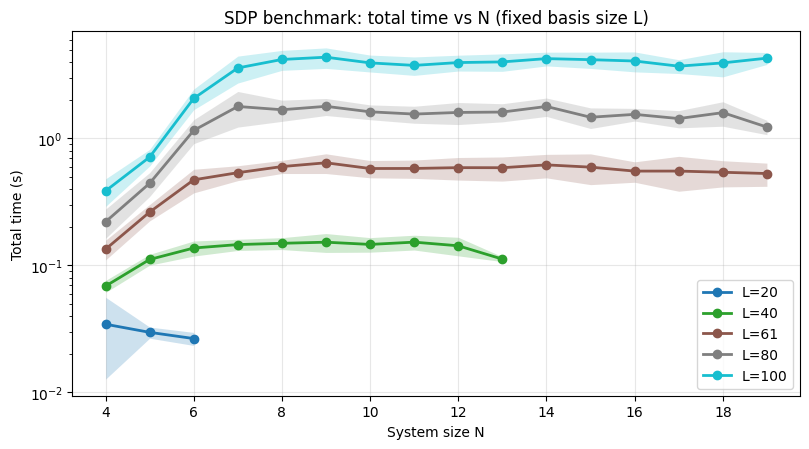

(<Figure size 820x460 with 1 Axes>,
 <Axes: title={'center': 'SDP benchmark: total time vs N (fixed basis size L)'}, xlabel='System size N', ylabel='Total time (s)'>)

In [2]:
# Plot total solve time vs N for one or more fixed basis sizes L (mean ± std)
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_byBasisSize.npz")

Ls_to_plot = [20,40,61,80,100]

sb.plot_total_time_vs_N_for_fixed_basis_sizes(
    npz_path,
    Ls_to_plot,
    yscale="log",
    title="SDP benchmark: total time vs N (fixed basis size L)",
)


In [3]:
# Benchmark fixed N while sweeping total basis size L (by translating L -> k for that N)
from pathlib import Path
import numpy as np
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

N_fixed = 10  # fixed system size
basis_sizes = list(range(100, 121, 5))  # desired total basis sizes
out_npz_fixedN = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")

for N in [N_fixed]:
    out_path = sb.compute_fixed_N_across_basis_size_and_save(
        N=N,
        basis_sizes=list([50,100,200]), #basis_sizes,
        model_name="heisenberg",
        model_params={},
        start_level=1,
        end_level=4,
        num_trials=1,
        mosek_tol=1e-9,
        out_root=Path("spins_sdp/results"),
        out_npz=out_npz_fixedN,
        verbose=True,
    )
    print(out_path)


Model: heisenberg, N=10, boundary=periodic
Starting set size: 31, Adding set size: 20655, Final set size: 20686
Total jobs: 3, Already done: 357, To compute: 3


SDP benchmark:  33%|███▎      | 1/3 [00:00<00:00,  4.16it/s, k=19, trial=9, basis=50, t_total_s=0.240, status=optimal]

Done k=19 trial=9: basis_size=50, moment_dim=50, n_moments=1172, obj=-7.108845, status=optimal, t_compile=0.004s, t_build=0.002s, t_solve=0.234s, t_total=0.240s


SDP benchmark:  67%|██████▋   | 2/3 [00:04<00:02,  2.32s/it, k=69, trial=12, basis=100, t_total_s=3.774, status=optimal]

Done k=69 trial=12: basis_size=100, moment_dim=100, n_moments=4770, obj=-6.901436, status=optimal, t_compile=0.012s, t_build=0.001s, t_solve=3.761s, t_total=3.774s


SDP benchmark: 100%|██████████| 3/3 [01:58<00:00, 39.42s/it, k=169, trial=0, basis=200, t_total_s=114.211, status=optimal]

Done k=169 trial=0: basis_size=200, moment_dim=200, n_moments=18690, obj=-6.570945, status=optimal, t_compile=0.055s, t_build=0.002s, t_solve=114.154s, t_total=114.211s
spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz


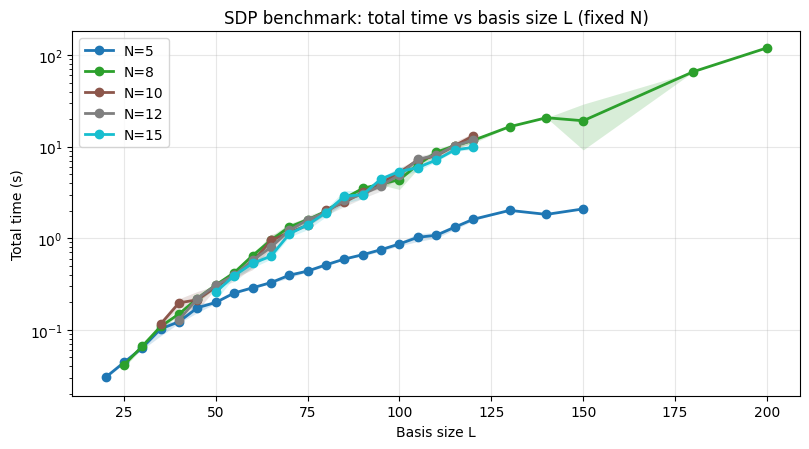

(<Figure size 820x460 with 1 Axes>,
 <Axes: title={'center': 'SDP benchmark: total time vs basis size L (fixed N)'}, xlabel='Basis size L', ylabel='Total time (s)'>)

In [4]:
# Plot total solve time vs basis size L for this fixed N (mean ± std)
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")

sb.plot_total_time_vs_basis_size_for_fixed_N(
    npz_path,
    [5, 8, 10, 12, 15],
    yscale="log",
    title="SDP benchmark: total time vs basis size L (fixed N)",
)


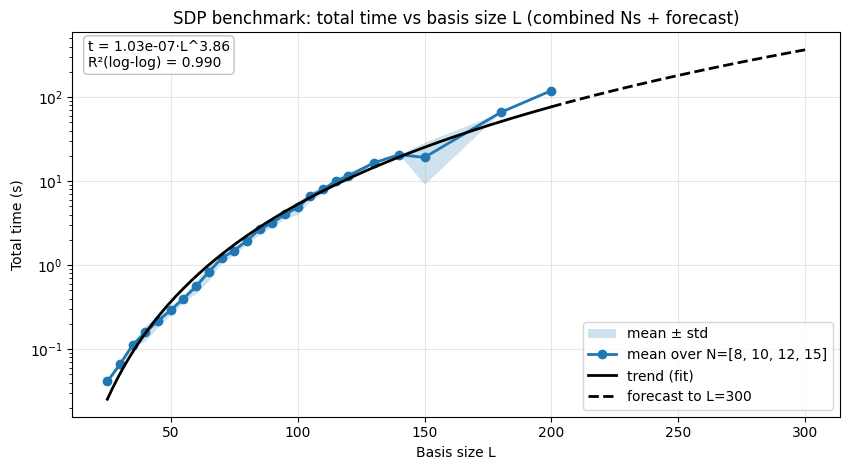

{'fit': 'power-law',
 'fit_L_min': 20,
 'fit_L_max': 200,
 'a': 1.0283544290894659e-07,
 'b': 3.85611475429724,
 'r2_loglog': 0.9903478738310474,
 'equation': 't=(1.028e-07)·L^(3.856)'}

In [25]:
# Combine multiple N values into a single time-vs-basis-size curve with trendline + forecast
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")
Ns_to_combine = [8, 10, 12, 15]

# Choose the window of L values used for the regression fit.
# The plotted trendline/forecast uses only this fit window to estimate (a, b).
fit_L_min = 20
fit_L_max = 200

fig, ax, fit_info = sb.plot_total_time_vs_basis_size_combined_Ns_with_forecast(
    npz_path,
    Ns_to_combine,
    fit="power-law",  # Changed from "log-linear" to "power-law"
    fit_L_min=fit_L_min,
    fit_L_max=fit_L_max,
    forecast_to_basis_size=300,  # increase as desired
    forecast_step=1,
    yscale="log",
    title="SDP benchmark: total time vs basis size L (combined Ns + forecast)",
)

fit_info

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis

# Paper basis: N up to 50
N_paper = range(2, 101)
paper_sizes = []
for N in N_paper:
    basis = generate_heisenberg_paper_basis(N=N)
    paper_sizes.append(len(basis))


# NPA level 4: N up to 10
N_npa4 = range(2, 11)
npa4_sizes = []
for N in N_npa4:
    basis = generate_npa_basis(N=N  , k=4)
    npa4_sizes.append(len(basis.words))
    print(f"N={N}, size={len(basis.words)}")


N=2, size=16
N=3, size=64
N=4, size=256
N=5, size=781
N=6, size=1909
N=7, size=3991
N=8, size=7459
N=9, size=12826
N=10, size=20686


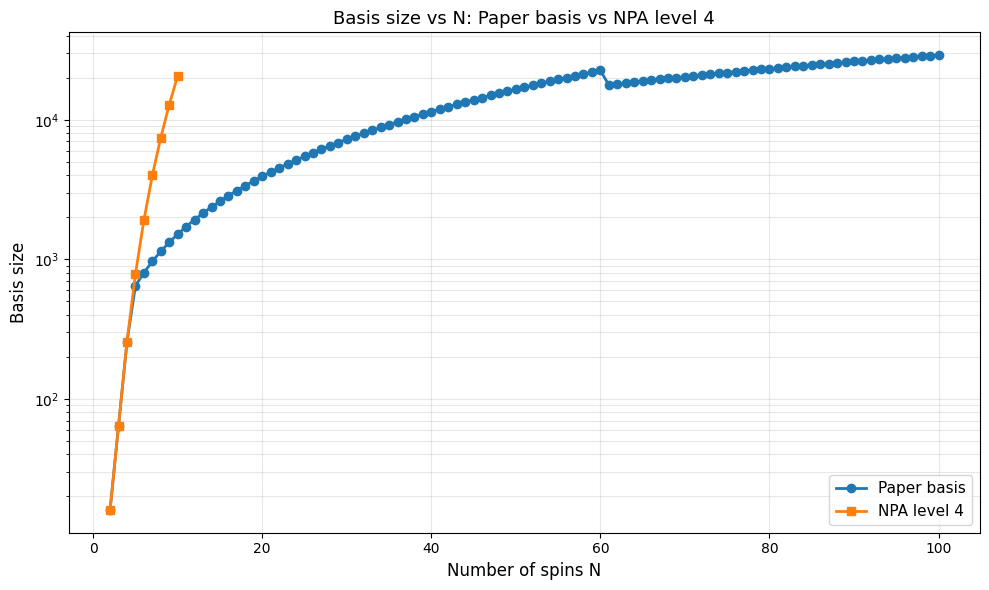

In [17]:

# Plot
plt.figure(figsize=(10, 6))
plt.plot(N_paper, paper_sizes, 'o-', linewidth=2, markersize=6, label='Paper basis')
plt.plot(N_npa4, npa4_sizes, 's-', linewidth=2, markersize=6, label='NPA level 4')
plt.yscale('log')
plt.xlabel('Number of spins N', fontsize=12)
plt.ylabel('Basis size', fontsize=12)
plt.title('Basis size vs N: Paper basis vs NPA level 4', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [9]:
# Print paper basis sizes for N=10,20,...,100
N_values = [6, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(f"{'N':<5} {'Basis Size':<12}")
print("-" * 17)
for N in N_values:
    idx = N - 2  # N_paper starts at 2
    if idx < len(paper_sizes):
        print(f"{N:<5} {paper_sizes[idx]:<12}")

N     Basis Size  
-----------------
6     802         
10    1516        
20    3931        
30    7246        
40    11461       
50    16576       
60    22591       
70    20371       
80    23281       
90    26191       
100   29101       


In [27]:
# Use the forecast from the graph above to estimate runtime for each N
import numpy as np

a = fit_info['a']
b = fit_info['b']

print(f"Forecast equation (power-law): t = {a:.4g} * L^{b:.4g}")
print(f"\nEstimated runtimes:")
print(f"{'N':<5} {'L':<7} {'Time (s)':<12} {'Days':<12} {'Months':<12} {'Years':<12}")
print("-" * 70)

for N in N_values:
    idx = N - 2
    if idx < len(paper_sizes):
        L = paper_sizes[idx]
        t_est = a * (L ** b)
        days = t_est / 86400
        months = days / 30.44  # average month length
        years = days / 365.25
        print(f"{N:<5} {L:<7} {t_est:<12.3e} {days:<12.3e} {months:<12.3e} {years:<12.3e}")

Forecast equation (power-law): t = 1.028e-07 * L^3.856

Estimated runtimes:
N     L       Time (s)     Days         Months       Years       
----------------------------------------------------------------------
10    1516    1.894e+05    2.192e+00    7.200e-02    6.000e-03   
20    3931    7.464e+06    8.639e+01    2.838e+00    2.365e-01   
30    7246    7.891e+07    9.133e+02    3.000e+01    2.500e+00   
40    11461   4.623e+08    5.351e+03    1.758e+02    1.465e+01   
50    16576   1.918e+09    2.220e+04    7.294e+02    6.079e+01   
60    22591   6.330e+09    7.327e+04    2.407e+03    2.006e+02   
70    20371   4.248e+09    4.917e+04    1.615e+03    1.346e+02   
80    23281   7.109e+09    8.228e+04    2.703e+03    2.253e+02   
90    26191   1.120e+10    1.296e+05    4.257e+03    3.548e+02   
100   29101   1.681e+10    1.945e+05    6.390e+03    5.326e+02   


In [5]:
from spins_sdp.sdp import solve_pauli_relaxation
from spins_sdp.basis_builder import generate_heisenberg_paper_basis
from spins_sdp.models import heisenberg_hamiltonian_dict

basis = generate_heisenberg_paper_basis(N=4)

H = heisenberg_hamiltonian_dict(N=4)

val_primal = solve_pauli_relaxation(basis, H, formulation="primal", solver="MOSEK")
print(f"Primal value: {val_primal}")

val_dual   = solve_pauli_relaxation(basis, H, formulation="dual",   solver="MOSEK")
print(f"Dual value:   {val_dual}")

TypeError: solve_pauli_relaxation() got an unexpected keyword argument 'formulation'

In [8]:
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis, split_basis_by_signature

N = 10

basis_paper = generate_heisenberg_paper_basis(N=N)
basis_1 = generate_npa_basis(N=N, k=1)
basis_2 = generate_npa_basis(N=N, k=2)

for sig in [(0,0), (1,0), (0,1), (1,1)]:
    paper_sig = split_basis_by_signature(basis_paper)[sig]
    npa1_sig  = split_basis_by_signature(basis_1.words)[sig]
    npa2_sig  = split_basis_by_signature(basis_2.words)[sig]
    print(f"Signature {sig}: Paper basis size = {len(paper_sig)}, NPA k1 size = {len(npa1_sig)}, NPA k2 size = {len(npa2_sig)}")

Signature (0, 0): Paper basis size = 406, NPA k1 size = 1, NPA k2 size = 136
Signature (1, 0): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100
Signature (0, 1): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100
Signature (1, 1): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100


N   | Orig (s)   | Block (s)  | FullSym (s) | FullSym3 (s) | Energy Diff 
-----------------------------------------------------------------
2   | 0.0153     | 0.0140     | 0.0119     | 0.0051     | 1.60e-10    
3   | 0.0317     | 0.0169     | 0.0160     | 0.0085     | 4.87e-09    
4   | 0.1333     | 0.0388     | 0.0287     | 0.0079     | 3.35e-07    
5   | 0.6516     | 0.0966     | 0.0670     | 0.0152     | 2.37e-02    
6   | 1.6403     | 0.2035     | 0.1271     | 0.0316     | 3.04e-07    
7   | 4.7397     | 0.5008     | 0.2969     | 0.0639     | 4.47e-02    
8   | 22.3421    | 1.7452     | 0.7854     | 0.1761     | 5.07e-03    
9   | 72.0329    | 3.7507     | 1.4798     | 0.2817     | 5.34e-02    
10  | -          | 10.6591    | 2.9416     | 0.5697     | 1.27e-02    
11  | -          | 27.0762    | 3.8875     | 0.8577     | 5.00e-02    
12  | -          | 53.4007    | 7.2349     | 1.6173     | 1.76e-02    
13  | -          | nan        | 12.2968    | 3.1577     | 4.25e-02    
14  | - 

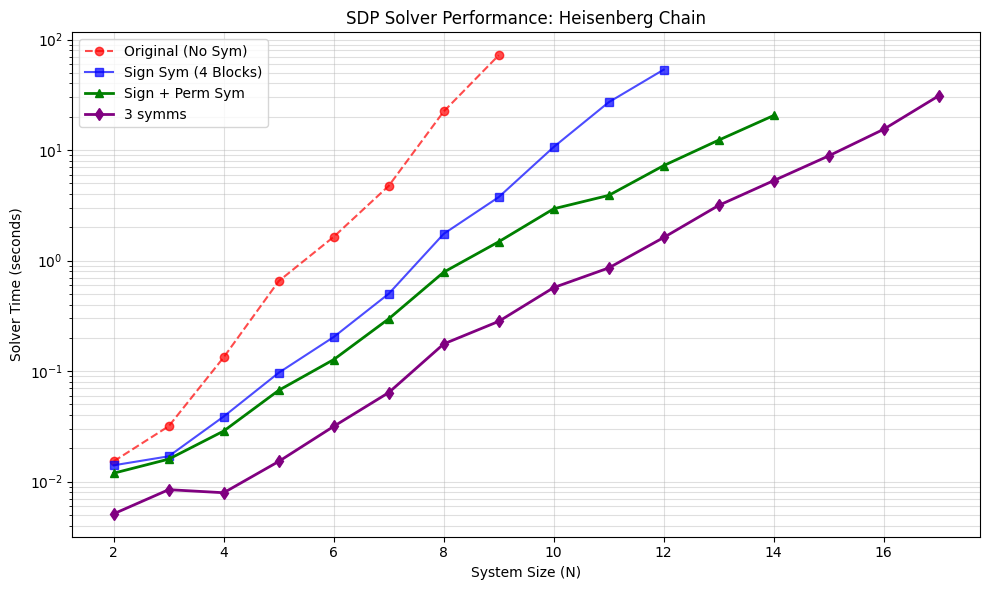

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import solvers
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis
from spins_sdp.models import heisenberg_hamiltonian_dict
from spins_sdp.sdp import (
    solve_pauli_relaxation,
    solve_pauli_relaxation3,
    solve_block_diagonal_pauli_relaxation,
    solve_symmetric_pauli_relaxation  # The new function
)

def run_benchmark():
    # Define system sizes to test
    # N=12 is usually the limit for Block Diagonal on standard laptops
    # The Full Symmetry might push slightly faster or allow N=14
    N_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,15,16,17]
    
    results = []

    print(f"{'N':<3} | {'Orig (s)':<10} | {'Block (s)':<10} | {'FullSym (s)':<10} | {'FullSym3 (s)':<10} | {'Energy Diff':<12}")
    print("-" * 65)

    for N in N_values:
        basis = generate_npa_basis(N=N, k=2).words
        ham = heisenberg_hamiltonian_dict(N=N)
        
        # 1. Original (Single Block) - Skip for N >= 12
        if N < 10:
            t0 = time.perf_counter()
            e_orig = solve_pauli_relaxation(basis, ham, verbose=False)
            t_orig = time.perf_counter() - t0
        else:
            e_orig = np.nan
            t_orig = np.nan
        
        # 2. Block Diagonal (Sign Symmetry)
        if N < 13:
            t0 = time.perf_counter()
            e_block = solve_block_diagonal_pauli_relaxation(basis, ham, verbose=False)
            t_block = time.perf_counter() - t0
        else:
            e_block = np.nan
            t_block = np.nan
        
        # 3. Full Symmetry (Sign + Permutation)
        if N < 15:
            t0 = time.perf_counter()
            e_sym = solve_symmetric_pauli_relaxation(basis, ham, verbose=False)
            t_sym = time.perf_counter() - t0
        else:
            e_sym = np.nan
            t_sym = np.nan
        
        # 4. Full Symmetry 3 (Sign + Permutation + Additional Symmetry)
        t0 = time.perf_counter()
        e_sym3 = solve_pauli_relaxation3(basis, ham, verbose=False)
        t_sym3 = time.perf_counter() - t0
        
        # Verification (Compare Sym vs Sym3)
        diff = abs(e_orig - e_sym3 if not np.isnan(e_orig) else e_sym - e_sym3)
        
        results.append({
            "N": N,
            "Time_Orig": t_orig,
            "Time_Block": t_block,
            "Time_Sym": t_sym,
            "Time_Sym3": t_sym3,
            "E_Block": e_block,
            "E_Sym": e_sym,
            "E_Sym3": e_sym3
        })
        
        # Print row
        t_o_s = f"{t_orig:.4f}" if not np.isnan(t_orig) else "-"
        print(f"{N:<3} | {t_o_s:<10} | {t_block:<10.4f} | {t_sym:<10.4f} | {t_sym3:<10.4f} | {diff:<12.2e}")

    # --- Plotting ---
    df = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    
    # Plot Original
    valid_orig = df[df["Time_Orig"].notna()]
    plt.plot(valid_orig["N"], valid_orig["Time_Orig"], 'o--', label='Original (No Sym)', color='red', alpha=0.7)
    
    # Plot Block
    plt.plot(df["N"], df["Time_Block"], 's-', label='Sign Sym (4 Blocks)', color='blue', alpha=0.7)
    
    # Plot Full Sym
    plt.plot(df["N"], df["Time_Sym"], '^-', label='Sign + Perm Sym', color='green', linewidth=2)
    
    # Plot Full Sym 3
    plt.plot(df["N"], df["Time_Sym3"], 'd-', label='3 symms', color='purple', linewidth=2)
    
    plt.xlabel('System Size (N)')
    plt.ylabel('Solver Time (seconds)')
    plt.title('SDP Solver Performance: Heisenberg Chain')
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return df

# Run
df_results = run_benchmark()

N    | Original   | Block      | FullSym    | Sym3       | Reduction_12 | Reduction_23 | Reduction_34 | Reduction_Total
------------------------------------------------------------------------------------------
3    | 64         | 16         | 5          | 4          | 4.0x | 3.2x | 1.2x | 16.0x
4    | 256        | 64         | 15         | 11         | 4.0x | 4.3x | 1.4x | 23.3x
5    | 1024       | 256        | 51         | 31         | 4.0x | 5.0x | 1.6x | 33.0x
6    | 4096       | 1024       | 187        | 107        | 4.0x | 5.5x | 1.7x | 38.3x
7    | 16384      | 4096       | 715        | 379        | 4.0x | 5.7x | 1.9x | 43.2x
8    | 63592      | 15904      | 2715       | 1451       | 4.0x | 5.9x | 1.9x | 43.8x
9    | 179038     | 44785      | 7582       | 4960       | 4.0x | 5.9x | 1.5x | 36.1x
10   | 304996     | 76306      | 12911      | 8561       | 4.0x | 5.9x | 1.5x | 35.6x


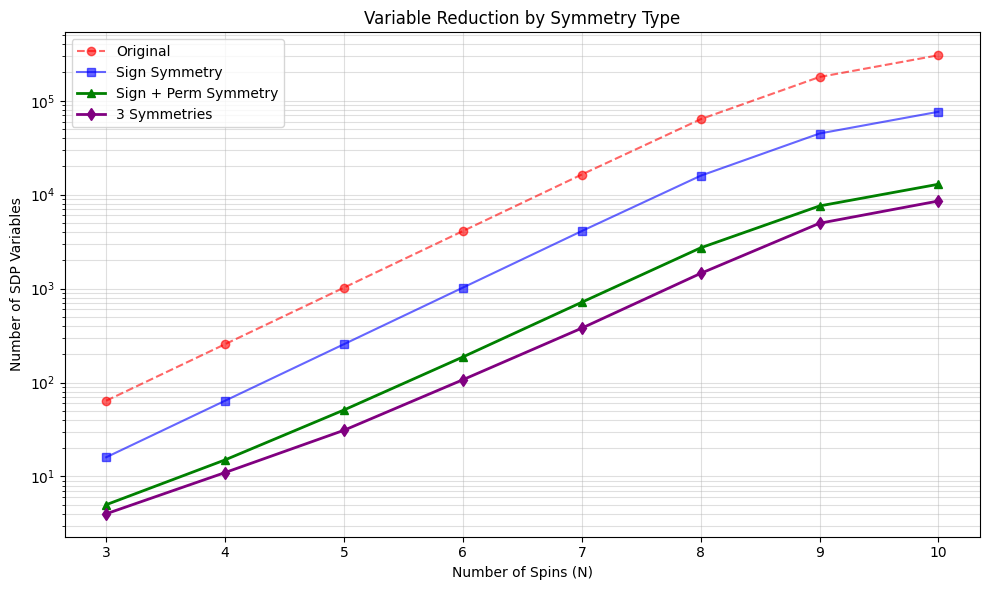

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Import from your updated library ---
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis
from spins_sdp.pauli import compile_moment_matrix_rep
from spins_sdp.sdp import build_block_reps, build_block_reps_3, build_block_reps_with_permutation

def run_variable_counting_benchmark():
    # We can go a bit higher with N since we are only counting, not solving
    #N_values = [4, 6, 8, 10, 12, 14, 16, 18, 20] 
    N_values = [3,4,5,6,7,8,9,10] 
    
    results = []

    print(f"{'N':<4} | {'Original':<10} | {'Block':<10} | {'FullSym':<10} | {'Sym3':<10} | {'Reduction_12':<12} | {'Reduction_23':<12} | {'Reduction_34':<12} | {'Reduction_Total':<15}")
    print("-" * 90)

    for N in N_values:
        # Generate Basis (Heisenberg paper basis, usually degree 3 or similar)
        basis = generate_heisenberg_paper_basis(N=N)
        
        # --- Method 1: Original (No Symmetry) ---
        # compile_moment_matrix_rep calculates all unique u = w_i * w_j
        # The number of unique labels is the number of variables.
        rep_orig = compile_moment_matrix_rep(basis)
        n_orig = len(rep_orig.labels)
        
        # --- Method 2: Sign Symmetry (Block Diagonal) ---
        # build_block_reps returns (reps, global_index)
        # global_index is the unified registry of unique variables across all blocks
        _, index_block = build_block_reps(basis)
        n_block = len(index_block)
        
        # --- Method 3: Sign + Permutation Symmetry ---
        # build_block_reps_with_permutation maps raw moments to canonical ones
        _, index_sym = build_block_reps_with_permutation(basis)
        n_sym = len(set(index_sym.values()))
        
        # -- Method 4
        _, index_sym3 = build_block_reps_3(basis)
        n_sym3 = len(set(index_sym3.values()))
        
        
        # Calculate Reduction Factor (Original / Best)
        reduction_12 = n_orig / n_block
        reduction_23 = n_block / n_sym
        reduction_34 = n_sym / n_sym3
        reduction_total = n_orig / n_sym3
        
        results.append({
            "N": N,
            "Original": n_orig,
            "Block": n_block,
            "FullSym": n_sym,
            "Sym3": n_sym3,
            "Reduction_12": reduction_12,
            "Reduction_23": reduction_23,
            "Reduction_34": reduction_34,
            "Reduction_Total": reduction_total
        })
        
        print(f"{N:<4} | {n_orig:<10} | {n_block:<10} | {n_sym:<10} | {n_sym3:<10} | {reduction_12:.1f}x | {reduction_23:.1f}x | {reduction_34:.1f}x | {reduction_total:.1f}x")

    # --- Plotting ---
    df = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(df["N"], df["Original"], 'o--', label='Original', color='red', alpha=0.6)
    plt.plot(df["N"], df["Block"], 's-', label='Sign Symmetry', color='blue', alpha=0.6)
    plt.plot(df["N"], df["FullSym"], '^-', label='Sign + Perm Symmetry', color='green', linewidth=2)
    plt.plot(df["N"], df["Sym3"], 'd-', label='3 Symmetries', color='purple', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Number of Spins (N)')
    plt.ylabel('Number of SDP Variables')
    plt.title('Variable Reduction by Symmetry Type')
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return df

# Run the benchmark
df_vars = run_variable_counting_benchmark()